# Taller 02 — Poda Alfa-Beta

In [1]:
%pip install matplotlib
import random
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
# ============================================================
# CONFIGURACIÓN DEL ÁRBOL
# ============================================================

# Opciones:
# "manual"     -> utiliza el árbol escrito en ARBOL_MANUAL
# "aleatorio"  -> genera automáticamente el árbol
MODO = "manual"

# Árbol del ejemplo del taller
ARBOL_MANUAL = [
    [3, -5, 2],
    [-5, -7, 4],
    [-9, 6, -8]
]

# Configuración para generación aleatoria
# Número TOTAL de niveles, incluyendo raíz y hojas
NIVELES = 3

# Número total de nodos hoja
NUM_HOJAS = 9

# Rango de valores posibles para las hojas
VALOR_MIN = -10
VALOR_MAX = 10

# Semilla para reproducibilidad
SEMILLA = 42

# Jugador inicial
# True = MAX comienza
# False = MIN comienza
MAX_COMIENZA = True


In [3]:
# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def es_hoja(nodo):
    return not isinstance(nodo, list)

def contar_hojas(arbol):
    if es_hoja(arbol):
        return 1
    return sum(contar_hojas(hijo) for hijo in arbol)

def profundidad_arbol(arbol):
    if es_hoja(arbol):
        return 1
    if len(arbol) == 0:
        return 1
    return 1 + max(profundidad_arbol(hijo) for hijo in arbol)

def validar_arbol(arbol):
    hojas = contar_hojas(arbol)
    niveles = profundidad_arbol(arbol)

    if niveles > 5:
        raise ValueError(
            f"El árbol tiene {niveles} niveles. El máximo permitido es 5."
        )

    if hojas > 50:
        raise ValueError(
            f"El árbol tiene {hojas} hojas. El máximo permitido es 50."
        )

    return True


In [4]:
# ============================================================
# GENERACIÓN ALEATORIA DEL ÁRBOL
# ============================================================

def repartir_hojas(total, partes):
    if partes == 1:
        return [total]

    cortes = sorted(random.sample(range(1, total), partes - 1))
    puntos = [0] + cortes + [total]

    return [
        puntos[i + 1] - puntos[i]
        for i in range(len(puntos) - 1)
    ]

def generar_arbol_aleatorio(
    niveles,
    num_hojas,
    valor_min=-10,
    valor_max=10
):
    if niveles < 1 or niveles > 5:
        raise ValueError("El número de niveles debe estar entre 1 y 5.")

    if num_hojas < 1 or num_hojas > 50:
        raise ValueError("El número de hojas debe estar entre 1 y 50.")

    if niveles == 1:
        if num_hojas != 1:
            raise ValueError(
                "Un árbol de un solo nivel solamente puede tener una hoja."
            )
        return random.randint(valor_min, valor_max)

    if niveles == 2:
        return [
            random.randint(valor_min, valor_max)
            for _ in range(num_hojas)
        ]

    if num_hojas == 1:
        numero_hijos = 1
    else:
        numero_hijos = random.randint(
            2,
            min(4, num_hojas)
        )

    distribucion = repartir_hojas(
        num_hojas,
        numero_hijos
    )

    hijos = []

    for hojas_hijo in distribucion:
        hijo = generar_arbol_aleatorio(
            niveles - 1,
            hojas_hijo,
            valor_min,
            valor_max
        )
        hijos.append(hijo)

    return hijos


In [5]:
# ============================================================
# CONSTRUCCIÓN DEL ÁRBOL
# ============================================================

if MODO.lower() == "aleatorio":
    random.seed(SEMILLA)

    arbol = generar_arbol_aleatorio(
        niveles=NIVELES,
        num_hojas=NUM_HOJAS,
        valor_min=VALOR_MIN,
        valor_max=VALOR_MAX
    )
else:
    arbol = ARBOL_MANUAL

validar_arbol(arbol)

print("Árbol utilizado:")
print(arbol)

print("\nNúmero de niveles:", profundidad_arbol(arbol))
print("Número de hojas:", contar_hojas(arbol))


Árbol utilizado:
[[3, -5, 2], [-5, -7, 4], [-9, 6, -8]]

Número de niveles: 3
Número de hojas: 9


In [6]:
# ============================================================
# VARIABLES DE REGISTRO
# ============================================================

nodos_visitados = set()
hojas_evaluadas = set()
nodos_podados = set()
mejor_hijo = {}
valores_calculados = {}
registro_podas = []


In [7]:
# ============================================================
# REGISTRO DE SUBÁRBOLES PODADOS
# ============================================================

def registrar_subarbol_podado(nodo, ruta):
    nodos_podados.add(ruta)

    if not es_hoja(nodo):
        for indice, hijo in enumerate(nodo):
            registrar_subarbol_podado(
                hijo,
                ruta + (indice,)
            )


In [8]:
# ============================================================
# ALGORITMO PODA ALFA-BETA
# ============================================================

def alfa_beta(
    nodo,
    alpha=-math.inf,
    beta=math.inf,
    maximizando=True,
    ruta=()
):
    nodos_visitados.add(ruta)

    # Caso base: hoja
    if es_hoja(nodo):
        hojas_evaluadas.add(ruta)
        valores_calculados[ruta] = nodo
        return nodo

    # Turno de MAX
    if maximizando:
        mejor_valor = -math.inf
        mejor_ruta = None

        for indice, hijo in enumerate(nodo):
            ruta_hijo = ruta + (indice,)

            valor = alfa_beta(
                hijo,
                alpha,
                beta,
                False,
                ruta_hijo
            )

            if valor > mejor_valor:
                mejor_valor = valor
                mejor_ruta = ruta_hijo

            alpha = max(alpha, mejor_valor)

            # Poda beta
            if beta <= alpha:
                for j in range(indice + 1, len(nodo)):
                    ruta_podada = ruta + (j,)

                    registrar_subarbol_podado(
                        nodo[j],
                        ruta_podada
                    )

                    registro_podas.append({
                        "tipo": "Beta",
                        "desde": ruta,
                        "rama": ruta_podada,
                        "alpha": alpha,
                        "beta": beta
                    })

                break

        mejor_hijo[ruta] = mejor_ruta
        valores_calculados[ruta] = mejor_valor
        return mejor_valor

    # Turno de MIN
    else:
        mejor_valor = math.inf
        mejor_ruta = None

        for indice, hijo in enumerate(nodo):
            ruta_hijo = ruta + (indice,)

            valor = alfa_beta(
                hijo,
                alpha,
                beta,
                True,
                ruta_hijo
            )

            if valor < mejor_valor:
                mejor_valor = valor
                mejor_ruta = ruta_hijo

            beta = min(beta, mejor_valor)

            # Poda alfa
            if beta <= alpha:
                for j in range(indice + 1, len(nodo)):
                    ruta_podada = ruta + (j,)

                    registrar_subarbol_podado(
                        nodo[j],
                        ruta_podada
                    )

                    registro_podas.append({
                        "tipo": "Alfa",
                        "desde": ruta,
                        "rama": ruta_podada,
                        "alpha": alpha,
                        "beta": beta
                    })

                break

        mejor_hijo[ruta] = mejor_ruta
        valores_calculados[ruta] = mejor_valor
        return mejor_valor


In [9]:
# ============================================================
# EJECUCIÓN DEL ALGORITMO
# ============================================================

nodos_visitados.clear()
hojas_evaluadas.clear()
nodos_podados.clear()
mejor_hijo.clear()
valores_calculados.clear()
registro_podas.clear()

resultado = alfa_beta(
    arbol,
    alpha=-math.inf,
    beta=math.inf,
    maximizando=MAX_COMIENZA,
    ruta=()
)

print("=" * 60)
print("RESULTADO DE PODA ALFA-BETA")
print("=" * 60)

print("\nValor óptimo del juego:", resultado)
print("\nNúmero de hojas totales:", contar_hojas(arbol))
print("Número de hojas evaluadas:", len(hojas_evaluadas))
print("Número de nodos podados:", len(nodos_podados))
print("Número de operaciones de poda:", len(registro_podas))


RESULTADO DE PODA ALFA-BETA

Valor óptimo del juego: -5

Número de hojas totales: 9
Número de hojas evaluadas: 5
Número de nodos podados: 4
Número de operaciones de poda: 4


In [10]:
# ============================================================
# SECUENCIA ÓPTIMA DE JUGADAS
# ============================================================

def obtener_secuencia_optima():
    ruta = ()
    secuencia = [ruta]

    while ruta in mejor_hijo:
        siguiente = mejor_hijo[ruta]

        if siguiente is None:
            break

        secuencia.append(siguiente)
        ruta = siguiente

    return secuencia

secuencia_optima = obtener_secuencia_optima()

print("Secuencia óptima:")

for i, ruta in enumerate(secuencia_optima):
    if ruta == ():
        print(f"Nivel {i + 1}: RAÍZ")
    else:
        print(f"Nivel {i + 1}: rama {ruta}")

ruta_final = secuencia_optima[-1]

if ruta_final in valores_calculados:
    print(
        "\nValor final de la secuencia óptima:",
        valores_calculados[ruta_final]
    )


Secuencia óptima:
Nivel 1: RAÍZ
Nivel 2: rama (0,)
Nivel 3: rama (0, 1)

Valor final de la secuencia óptima: -5


In [11]:
# ============================================================
# INFORMACIÓN SOBRE LAS PODAS
# ============================================================

if len(registro_podas) == 0:
    print("No se realizaron podas.")
else:
    print("Podas realizadas:\n")

    for i, poda in enumerate(registro_podas, start=1):
        print(
            f"{i}. Poda {poda['tipo']} | "
            f"Nodo: {poda['desde']} | "
            f"Rama podada: {poda['rama']} | "
            f"α = {poda['alpha']} | "
            f"β = {poda['beta']}"
        )


Podas realizadas:

1. Poda Alfa | Nodo: (1,) | Rama podada: (1, 1) | α = -5 | β = -5
2. Poda Alfa | Nodo: (1,) | Rama podada: (1, 2) | α = -5 | β = -5
3. Poda Alfa | Nodo: (2,) | Rama podada: (2, 1) | α = -5 | β = -9
4. Poda Alfa | Nodo: (2,) | Rama podada: (2, 2) | α = -5 | β = -9


In [12]:
# ============================================================
# PREPARACIÓN PARA LA VISUALIZACIÓN
# ============================================================

def construir_nodos(
    nodo,
    ruta=(),
    profundidad=0,
    nodos=None,
    aristas=None
):
    if nodos is None:
        nodos = {}

    if aristas is None:
        aristas = []

    nodos[ruta] = {
        "objeto": nodo,
        "profundidad": profundidad
    }

    if not es_hoja(nodo):
        for indice, hijo in enumerate(nodo):
            ruta_hijo = ruta + (indice,)
            aristas.append((ruta, ruta_hijo))

            construir_nodos(
                hijo,
                ruta_hijo,
                profundidad + 1,
                nodos,
                aristas
            )

    return nodos, aristas


In [13]:
# ============================================================
# POSICIONAMIENTO DEL ÁRBOL
# ============================================================

def obtener_hojas_grafico(nodo, ruta=()):
    if es_hoja(nodo):
        return [ruta]

    hojas = []

    for indice, hijo in enumerate(nodo):
        hojas.extend(
            obtener_hojas_grafico(
                hijo,
                ruta + (indice,)
            )
        )

    return hojas

def calcular_posiciones(arbol):
    hojas = obtener_hojas_grafico(arbol)
    posiciones = {}

    # Posición horizontal de las hojas
    for i, ruta in enumerate(hojas):
        posiciones[ruta] = (
            float(i),
            -(len(ruta))
        )

    # Posición de nodos internos
    def asignar_posicion(nodo, ruta=()):
        if es_hoja(nodo):
            return posiciones[ruta][0]

        posiciones_hijos = []

        for indice, hijo in enumerate(nodo):
            ruta_hijo = ruta + (indice,)

            x_hijo = asignar_posicion(
                hijo,
                ruta_hijo
            )

            posiciones_hijos.append(x_hijo)

        x = sum(posiciones_hijos) / len(posiciones_hijos)
        y = -len(ruta)

        posiciones[ruta] = (x, y)

        return x

    asignar_posicion(arbol)

    return posiciones


In [14]:
# ============================================================
# FUNCIONES AUXILIARES PARA LA FIGURA
# ============================================================

def jugador_en_nodo(ruta):
    profundidad = len(ruta)

    if MAX_COMIENZA:
        return "MAX" if profundidad % 2 == 0 else "MIN"
    else:
        return "MIN" if profundidad % 2 == 0 else "MAX"

def obtener_etiqueta(nodo, ruta):
    if es_hoja(nodo):
        return str(nodo)

    jugador = jugador_en_nodo(ruta)

    if ruta in valores_calculados:
        return f"{jugador}\n{valores_calculados[ruta]}"
    else:
        return jugador


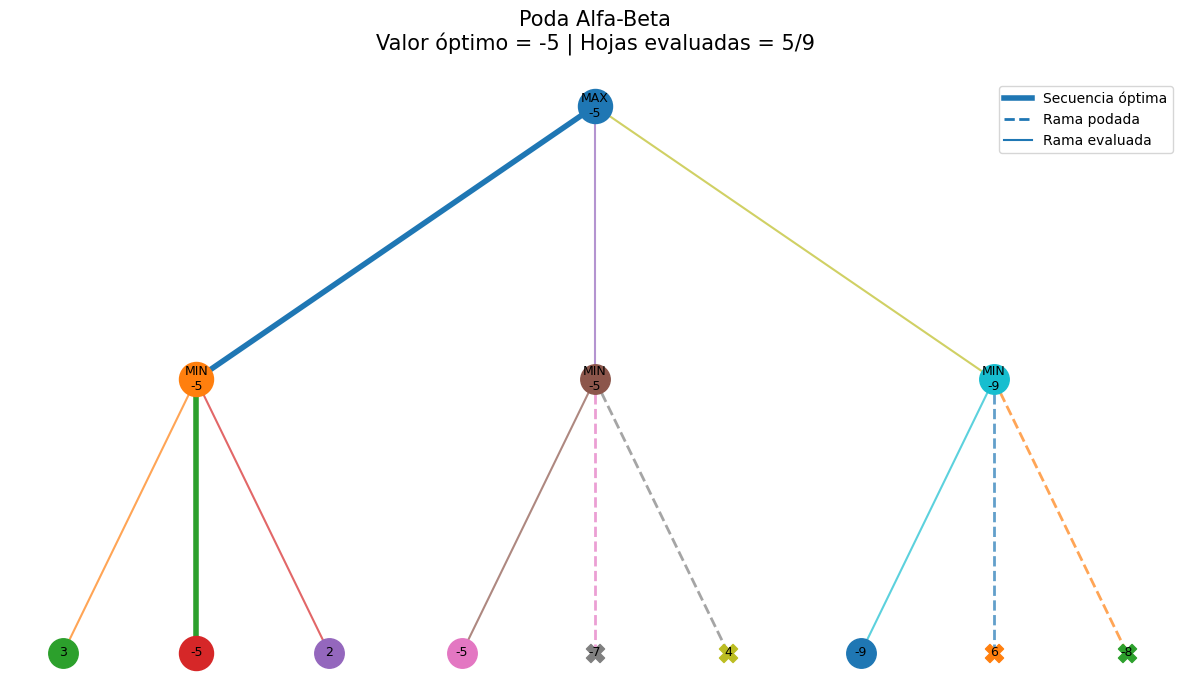

In [15]:
# ============================================================
# VISUALIZACIÓN DEL RESULTADO
# ============================================================

def dibujar_resultado(arbol):
    nodos, aristas = construir_nodos(arbol)
    posiciones = calcular_posiciones(arbol)
    secuencia = obtener_secuencia_optima()

    aristas_optimas = set()

    for i in range(len(secuencia) - 1):
        aristas_optimas.add(
            (
                secuencia[i],
                secuencia[i + 1]
            )
        )

    numero_hojas = contar_hojas(arbol)
    niveles = profundidad_arbol(arbol)

    ancho = max(12, numero_hojas * 0.85)
    alto = max(7, niveles * 2.0)

    plt.figure(figsize=(ancho, alto))

    # Dibujar aristas
    for padre, hijo in aristas:
        x1, y1 = posiciones[padre]
        x2, y2 = posiciones[hijo]

        if hijo in nodos_podados:
            plt.plot(
                [x1, x2],
                [y1, y2],
                linestyle="--",
                linewidth=2,
                alpha=0.7
            )
        elif (padre, hijo) in aristas_optimas:
            plt.plot(
                [x1, x2],
                [y1, y2],
                linewidth=4
            )
        else:
            plt.plot(
                [x1, x2],
                [y1, y2],
                linewidth=1.5,
                alpha=0.7
            )

    # Dibujar nodos
    for ruta, informacion in nodos.items():
        nodo = informacion["objeto"]
        x, y = posiciones[ruta]

        if ruta in nodos_podados:
            marcador = "X"
            tamano = 170
        elif ruta in secuencia:
            marcador = "o"
            tamano = 600
        else:
            marcador = "o"
            tamano = 450

        plt.scatter(
            x,
            y,
            s=tamano,
            marker=marcador,
            zorder=3
        )

        etiqueta = obtener_etiqueta(nodo, ruta)

        plt.text(
            x,
            y,
            etiqueta,
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=9,
            zorder=4
        )

    titulo = (
        "Poda Alfa-Beta\n"
        f"Valor óptimo = {resultado} | "
        f"Hojas evaluadas = {len(hojas_evaluadas)}/"
        f"{contar_hojas(arbol)}"
    )

    plt.title(
        titulo,
        fontsize=15,
        pad=20
    )

    leyenda = [
        Line2D(
            [0],
            [0],
            linewidth=4,
            label="Secuencia óptima"
        ),
        Line2D(
            [0],
            [0],
            linestyle="--",
            linewidth=2,
            label="Rama podada"
        ),
        Line2D(
            [0],
            [0],
            linewidth=1.5,
            label="Rama evaluada"
        )
    ]

    plt.legend(
        handles=leyenda,
        loc="upper right"
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

dibujar_resultado(arbol)


In [16]:
# ============================================================
# RESUMEN FINAL
# ============================================================

print("=" * 70)
print("RESUMEN DEL ALGORITMO")
print("=" * 70)

print(f"""
Árbol:
{arbol}

Jugador inicial:
{"MAX" if MAX_COMIENZA else "MIN"}

Número de niveles:
{profundidad_arbol(arbol)}

Número total de hojas:
{contar_hojas(arbol)}

Valor óptimo:
{resultado}

Hojas evaluadas:
{len(hojas_evaluadas)}

Hojas evitadas gracias a la poda:
{contar_hojas(arbol) - len(hojas_evaluadas)}

Número de operaciones de poda:
{len(registro_podas)}

Secuencia óptima:
{obtener_secuencia_optima()}
""")


RESUMEN DEL ALGORITMO

Árbol:
[[3, -5, 2], [-5, -7, 4], [-9, 6, -8]]

Jugador inicial:
MAX

Número de niveles:
3

Número total de hojas:
9

Valor óptimo:
-5

Hojas evaluadas:
5

Hojas evitadas gracias a la poda:
4

Número de operaciones de poda:
4

Secuencia óptima:
[(), (0,), (0, 1)]

